In [1]:
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline
import pandas as pd
from rubin_sim.maf import radar
import os

from matplotlib.legend_handler import HandlerErrorbar


In [2]:
def norm_df(
    df,
    runs,
    cols,
    norm_run="baseline",
    invert_cols=None,
    reverse_cols=None,
    run_label="run_name",
    mag_cols=[],
):
    """
    Normalize values in a dataframe to a given run
    Parameters
    ----------
    df : pandas.DataFrame
        The input data frame
    runs : list of str
        A list of run numes
    cols : list of str
        A list of columns in df to use
    norm_run : str
        The row to use to normalize things to
    invert_cols : list of str
        A list of column names that should be inverted (e.g., columns that
        are uncertainties and are better with a smaller value)
    reverse_cols : list of str
        Columns to reverse (e.g., magnitudes)
    run_label : str (run_name)
        The column that has run names
    mag_cols : list of str
        Columns that are in magnitudes
    """
    indices = [np.max(np.where(df.index == name)[0]) for name in runs]
    out_df = df[cols].iloc[indices].copy()
    if reverse_cols is not None:
        for colname in reverse_cols:
            out_df[colname] = -out_df[colname]
    if invert_cols is not None:
        for colname in invert_cols:
            out_df[colname] = 1.0 / out_df[colname]
    if norm_run is not None:
        indx = np.max(np.where(out_df.index == norm_run)[0])
        for col in out_df.columns:
            # maybe just check that it's not a
            if col != "run_name":
                if (col in mag_cols) | (mag_cols == "all"):
                    out_df[col] = 1.0 + (out_df[col] - out_df[col].iloc[indx])
                else:
                    out_df[col] = (
                        1.0
                        + (out_df[col] - out_df[col].iloc[indx])
                        / out_df[col].iloc[indx]
                    )
    return out_df

In [3]:
data_loaded = pd.read_hdf('summary.h5')
data_loaded.shape


(10, 43909)

In [4]:
indx = np.isfinite(data_loaded["best18k Parallax fiveSigmaDepth, band, seeingFwhmGeom, ra_pi_amp, dec_pi_amp HealpixSlicer"].values)
data_loaded.loc[indx, ["best18k Parallax fiveSigmaDepth, filter, seeingFwhmGeom, ra_pi_amp, dec_pi_amp HealpixSlicer"]] = data_loaded["best18k Parallax fiveSigmaDepth, band, seeingFwhmGeom, ra_pi_amp, dec_pi_amp HealpixSlicer"].iloc[indx]

#for bandname in 'ugrizy':
#    indx = np.isfinite(data_loaded["Median CoaddM5 band%s HealpixSlicer" % bandname].values)
#    d1 = data_loaded["Median CoaddM5 %s HealpixSlicer" % bandname].values
#    d1[indx] = data_loaded["Median CoaddM5 band%s HealpixSlicer" % bandname].iloc[indx].values
#    data_loaded["Median CoaddM5 %s HealpixSlicer" % bandname] = d1

In [5]:
# Pull out the metrics we are interested in and define simple names

name_dict = {'FootprintFraction N year 1 u and night < 365 HealpixSlicer': 'Y1,u',
            'FootprintFraction N year 1 g and night < 365 HealpixSlicer': 'Y1,g',
            'FootprintFraction N year 1 r and night < 365 HealpixSlicer': 'Y1,r',

            'FootprintFraction N year 1 i and night < 365 HealpixSlicer': 'Y1,i',
    'best18k Parallax fiveSigmaDepth, filter, seeingFwhmGeom, ra_pi_amp, dec_pi_amp HealpixSlicer': 'parallax best 18k',
            'best18k properMotion HealpixSlicer': 'proper motion best 18k',
            'Fraction detected of total (mean) MicrolensingMetric_detect tE 20_30 days UserPointsSlicer': '20-30d microlensing\ndetection',
            'Fraction detected of total (mean) MicrolensingMetric_detect tE 60_90 days UserPointsSlicer': '60-90d microlensing\ndetection',
            'fONv MedianNvis fO HealpixSlicer': 'fO N vis',
             #'fOArea_750 fO All sky HealpixSlicer': 'fO Area 750',
            'Total detected SNNSNMetric_reducen_sn DDF excluded HealpixSlicer': 'SNe, N',
             'Median SNNSNMetric_reducezlim DDF excluded HealpixSlicer': 'SNe, zlim',
            '3x2ptFoM Exgalm5WithCuts i band non-DD year 10 HealpixSlicer': '3x2 i-band',
            'Median WeakLensingNvisits gri band non-DD HealpixSlicer': 'WL Nvis \ni-band',
            #'Total detected KNePopMetric_all_ztfrest_simple all models UserPointsSlicer': 'KNe ZTF simple',
            #'Total detected KNePopMetric_single_ztfrest_simple single model UserPointsSlicer': 'KNe single model',
            #'Sum PrestoKNe_score_p UserPointsSlicer': 'KNe Score, P',
            'Sum ColorSlope visitExposureTime > 19 HealpixSlicer': 'color slope',
            "Sum ColorSlope2Night visitExposureTime > 19 HealpixSlicer": "2day\ncolor slope",
            'Total detected XRBPopMetric_early_detect UserPointsSlicer': 'XRB\nearly detect',
            'VolumeSum Brown Dwarf, L7 HealpixSlicer': 'Brown Dwarf Vol',
            'CumulativeCompleteness H <= 16.000000 DiscoveryNChances NEO 3 pairs in 15 nights SNR=3 detection loss MoObjSlicer': 'NEO bright',
            'CumulativeCompleteness H <= 22.000000 DiscoveryNChances NEO 3 pairs in 15 nights SNR=3 detection loss MoObjSlicer': 'NEO faint',
            'CumulativeCompleteness H <= 6.000000 DiscoveryNChances TNO 3 pairs in 15 nights SNR=3 detection loss MoObjSlicer': 'TNO',
            'CumulativeCompleteness H <= 20.000000 DiscoveryNChances MBA 3 pairs in 15 nights SNR=3 detection loss MoObjSlicer': 'MBA',
            'CumulativeCompleteness H <= 18.000000 DiscoveryNChances Trojan 3 pairs in 15 nights SNR=3 detection loss MoObjSlicer': 'Trojan',
            'CumulativeCompleteness H <= 16.000000 DiscoveryNChances Vatira 1 quad in 1 night detection loss MoObjSlicer': 'Vatira',
            # 'CumulativeCompleteness H <= 16.000000 DiscoveryNChances Vatira 3 pairs in 15 nights SNR=5 detection loss MoObjSlicer': 'Vatira 3pairs, 15days, snr=5',
            #'CumulativeCompleteness H <= 20.000000 DiscoveryNChances PHA 1 quad in 1 night detection loss MoObjSlicer': 'PHA, quad',
            #'Fraction detected of total (mean) KNePopMetric_single_multi_color_detect single model UserPointsSlicer': "KNe\n multi-color"
            }
            
# drop in the units for the columns
units = {'parallax best 18k': 'mas',
         'proper motion best 18k': 'mas/yr',
         '20-30d microlensing\ndetection': 'fraction', 
         '60-90d microlensing\ndetection': 'fraction', 
         'fO N vis' : '', 
         'fO Area 750': '',
         'SNe, N': '', 
         'SNe, zlim': '', 
         '3x2 i-band': 'score', 
         'WL Nvis \ni-band': '', 
         'KNe ZTF simple': 'N', 
         'KNe single model': 'N',
         'KNe Score, P': 'score',
         'XRB\nearly detect': 'N', 
         'Brown Dwarf Vol': 'pc^3', 
         'NEO bright': 'fraction', 
         'NEO faint': 'fraction', 
         'TNO': 'fraction', 
         'MBA':'fraction',
         'Trojan': 'fraction',
         'Vatira': 'fraction',
         'Vatira 3pairs, 15days, snr=5': "fraction",
         'PHA, quad': 'fraction',
         'Y1,u': '',
         'Y1,g': '',
         'Y1,r': '',
         'Y1,i': '',
         'color slope': 'N',
         '2day\ncolor slope': 'N',
         "KNe\n multi-color": "fraction",
        }

# If columns are uncertainties, we want to plot them backwards
invert_cols = ['parallax best 18k', 'proper motion best 18k']
# If columns are mags or fractions, we want to plot differences, not fractional differences.
mag_cols = ['20-30d microlensing\ndetection', '60-90d microlensing\ndetection','SNe, zlim',
            'NEO bright', 'NEO faint', 'TNO', 'Vatira', 'MBA', 'Trojan',
           'u', 'g', 'r', 'i', 'z', 'y']

data = pd.DataFrame()
for key in name_dict:
    data[name_dict[key]] = data_loaded[key]
    

mag_dict = {'Median CoaddM5 g HealpixSlicer': 'g',
 'Median CoaddM5 i HealpixSlicer': 'i',
 'Median CoaddM5 r HealpixSlicer': 'r',
 'Median CoaddM5 u HealpixSlicer': 'u',
 'Median CoaddM5 y HealpixSlicer': 'y',
 'Median CoaddM5 z HealpixSlicer': 'z'}

mag_data = pd.DataFrame()
for key in mag_dict:
    mag_data[mag_dict[key]] = data_loaded[key]
    
    
    
ddf_dict = {'Sum SNNSNMetric DD:COSMOS_reducen_sn DD:COSMOS all bands, only DDF observations HealpixSubsetSlicer' : 'N SN COSMOS',
           'Sum SNNSNMetric DD:ECDFS_reducen_sn DD:ECDFS all bands, only DDF observations HealpixSubsetSlicer' : 'N SN ECDFS',
           'Sum SNNSNMetric DD:EDFS_reducen_sn DD:EDFS all bands, only DDF observations HealpixSubsetSlicer' : 'N SN EDFS',
           'Sum SNNSNMetric DD:ELAISS1_reducen_sn DD:ELAISS1 all bands, only DDF observations HealpixSubsetSlicer' : 'N SN ELAISS1',
           'Sum SNNSNMetric DD:XMM_LSS_reducen_sn DD:XMM_LSS all bands, only DDF observations HealpixSubsetSlicer' : 'N SN XMM_LSS',
            
           'Median SNNSNMetric DD:COSMOS_reducezlim DD:COSMOS all bands, only DDF observations HealpixSubsetSlicer': 'zlim COSMOS',
            'Median SNNSNMetric DD:ECDFS_reducezlim DD:ECDFS all bands, only DDF observations HealpixSubsetSlicer': 'zlim ECDFS',
            'Median SNNSNMetric DD:EDFS_reducezlim DD:EDFS all bands, only DDF observations HealpixSubsetSlicer': 'zlim EDFS',
            'Median SNNSNMetric DD:ELAISS1_reducezlim DD:ELAISS1 all bands, only DDF observations HealpixSubsetSlicer': 'zlim ELAISS1',
            'Median SNNSNMetric DD:XMM_LSS_reducezlim DD:XMM_LSS all bands, only DDF observations HealpixSubsetSlicer': 'zlim XMM_LSS',
            
           'Total detected KNePopMetric_DD:COSMOS_ztfrest_simple DD:COSMOS UserPointsSlicer': 'Kne COSMOS',
         'Total detected KNePopMetric_DD:ECDFS_ztfrest_simple DD:ECDFS UserPointsSlicer': 'Kne ECDFS',
 'Total detected KNePopMetric_DD:EDFS_ztfrest_simple DD:EDFS UserPointsSlicer': 'Kne EDFS',
 'Total detected KNePopMetric_DD:ELAISS1_ztfrest_simple DD:ELAISS1 UserPointsSlicer': 'Kne ELAISS1',
 'Total detected KNePopMetric_DD:WFD_ztfrest_simple DD:WFD UserPointsSlicer': 'Kne WFD',
 'Total detected KNePopMetric_DD:XMM_LSS_ztfrest_simple DD:XMM_LSS UserPointsSlicer': 'Kne XMM_LSS',
            
            'Median DD:COSMOS NVisits all bands HealpixSubsetSlicer':'N COSMOS',
 'Median DD:ECDFS NVisits all bands HealpixSubsetSlicer': 'N ECDFS',
 'Median DD:EDFS NVisits all bands HealpixSubsetSlicer': 'N EDFS',
 'Median DD:ELAISS1 NVisits all bands HealpixSubsetSlicer': 'N ELAISS1',
 'Median DD:WFD NVisits all bands HealpixSubsetSlicer': 'N WFD',
 'Median DD:XMM_LSS NVisits all bands HealpixSubsetSlicer': 'N XMM_LSS', 
           }

ddf_data = pd.DataFrame()
for key in ddf_dict:
    ddf_data[ddf_dict[key]] = data_loaded[key]
 
gaps_dict = {}
for filtername in 'ugrizy':
    for times in [3,7,24]:
        gaps_dict['Mean N gaps in %s at %ihr in top 18k Gaps_%ihr %s band HealpixSlicer'% (filtername, times, times, filtername)] = 'gaps %s %i' % (filtername, times)
        #gaps_dict['Mean Gaps_%ihr %s band HealpixSlicer' % (times, filtername)] = 'gaps %s %i' % (filtername, times)
        
gaps_data = pd.DataFrame()
for key in gaps_dict:
    gaps_data[gaps_dict[key]] = data_loaded[key]

In [6]:
data_loaded

metric,10th%ile CoaddM5 HealpixSlicer,10th%ile CoaddM5 g HealpixSlicer,10th%ile CoaddM5 i HealpixSlicer,10th%ile CoaddM5 r HealpixSlicer,10th%ile CoaddM5 u HealpixSlicer,10th%ile CoaddM5 y HealpixSlicer,10th%ile CoaddM5 z HealpixSlicer,10th%ile Count observationStartMJD HealpixSlicer,10th%ile Count observationStartMJD g HealpixSlicer,10th%ile Count observationStartMJD i HealpixSlicer,...,top18k Count observationStartMJD y HealpixSlicer,top18k Count observationStartMJD z HealpixSlicer,top18k N ToO g and scheduler_note like ToO% HealpixSlicer,top18k N ToO i and scheduler_note like ToO% HealpixSlicer,top18k N ToO r and scheduler_note like ToO% HealpixSlicer,top18k N ToO u and scheduler_note like ToO% HealpixSlicer,top18k N ToO y and scheduler_note like ToO% HealpixSlicer,top18k N ToO z and scheduler_note like ToO% HealpixSlicer,top18k Year1.0Count night < 365.25 HealpixSlicer,"best18k Parallax fiveSigmaDepth, filter, seeingFwhmGeom, ra_pi_amp, dec_pi_amp HealpixSlicer"
run_name,,,,,,,,,,,,,,,,,,,,,
baseline_v5.3.2_1yrs,25.748896,25.425872,24.370913,24.933795,24.399775,23.139902,23.924312,30.0,5.0,5.0,...,8.0,8.0,4.0,1.0,1.0,1.0,NaN,1.0,50.0,2.562924
baseline_v5.3.2_2yrs,25.842405,25.510100,24.537176,25.109189,24.434016,23.344463,24.032750,38.0,6.0,8.0,...,14.0,15.0,1.0,1.0,1.0,1.0,1.0,1.0,50.0,1.896614
desi_five_v5.3.2_1yrs,25.724498,25.381971,24.342166,24.965248,24.327562,23.126428,23.848573,29.0,4.0,5.0,...,7.0,7.0,4.0,1.0,1.0,1.0,NaN,1.0,46.0,2.684180
desi_five_v5.3.2_2yrs,25.801993,25.476450,24.528998,25.089384,24.388381,23.309051,23.955367,34.0,5.0,7.0,...,12.0,14.0,1.0,1.0,1.0,1.0,1.0,1.0,46.0,1.963565
desi_yearly_v5.3.1_1yrs,25.767638,25.444314,24.344453,24.994052,24.413917,23.109674,23.895219,30.0,5.0,5.0,...,7.0,8.0,4.0,1.0,1.0,1.0,NaN,1.0,49.0,2.578279
desi_yearly_v5.3.1_2yrs,25.835486,25.504285,24.520489,25.102499,24.443725,23.275048,23.976975,35.0,6.0,7.0,...,12.0,14.0,1.0,1.0,1.0,1.0,1.0,1.0,49.0,1.929859
faster_templates_v5.3.0_1yrs,25.559745,25.213948,24.248489,24.809613,24.101211,23.005169,23.843664,34.0,5.0,6.0,...,10.0,11.0,4.0,1.0,1.0,1.0,NaN,1.0,61.0,2.364295
faster_templates_v5.3.0_2yrs,25.678279,25.325914,24.412032,24.969377,24.139389,23.256080,23.952731,42.0,7.0,9.0,...,16.0,17.0,1.0,1.0,1.0,1.0,1.0,1.0,61.0,1.822437
no_template_v5.3.2_1yrs,25.210917,24.846240,24.152815,24.746473,23.384772,22.903052,23.312293,15.0,2.0,4.0,...,8.0,8.0,4.0,1.0,1.0,1.0,NaN,1.0,50.0,2.687663


In [7]:
# [name for name in mag_data.index if "prod" in name]

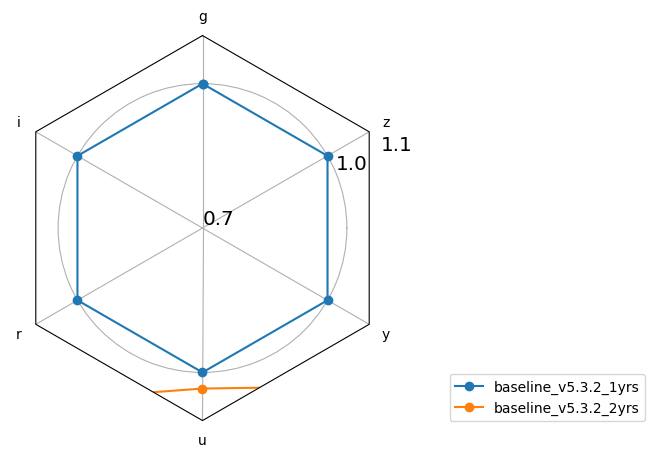

In [8]:
runs = [ 'baseline_v5.3.2_1yrs', 'baseline_v5.3.2_2yrs']
ndata = norm_df(mag_data, runs, cols=mag_data.columns.values.tolist(),
                 mag_cols = mag_cols, norm_run='baseline_v5.3.2_1yrs')#, invert_cols=['u', 'g', 'r', 'i', 'z', 'y'])
fig, ax = radar(ndata, legend=True, rgrids=[0.7, 1.0, 1.1], bbox_to_anchor=(1.65, 0))


In [9]:
mag_data.loc[runs]

,g,i,r,u,y,z
run_name,,,,,,
baseline_v5.3.2_1yrs,25.829530,24.796980,25.397007,24.734130,23.447546,24.321458
baseline_v5.3.2_2yrs,25.986544,25.409559,25.862578,24.767594,23.798676,24.701886


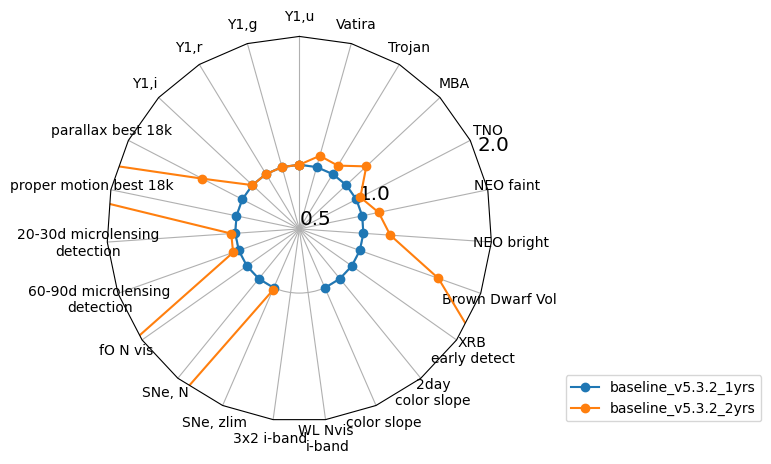

In [10]:
ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.2_1yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.5, 1.0, 2], bbox_to_anchor=(1.7, 0))


In [11]:
ndata

,"Y1,u","Y1,g","Y1,r","Y1,i",parallax best 18k,proper motion best 18k,20-30d microlensing\ndetection,60-90d microlensing\ndetection,fO N vis,"SNe, N",...,color slope,2day\ncolor slope,XRB\nearly detect,Brown Dwarf Vol,NEO bright,NEO faint,TNO,MBA,Trojan,Vatira
run_name,,,,,,,,,,,,,,,,,,,,,
baseline_v5.3.2_1yrs,1.0,1.0,1.0,1.0,1.000000,1.000000,1.0000,1.0000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.0000,1.00000,1.00000,1.000000,1.000000,1.0000
baseline_v5.3.2_2yrs,1.0,1.0,1.0,1.0,1.351316,5.205716,1.0317,1.0476,2.357143,4.851141,...,11.321496,3.509066,2.310811,1.650099,1.2102,1.13128,1.03569,1.214049,1.077346,1.0917


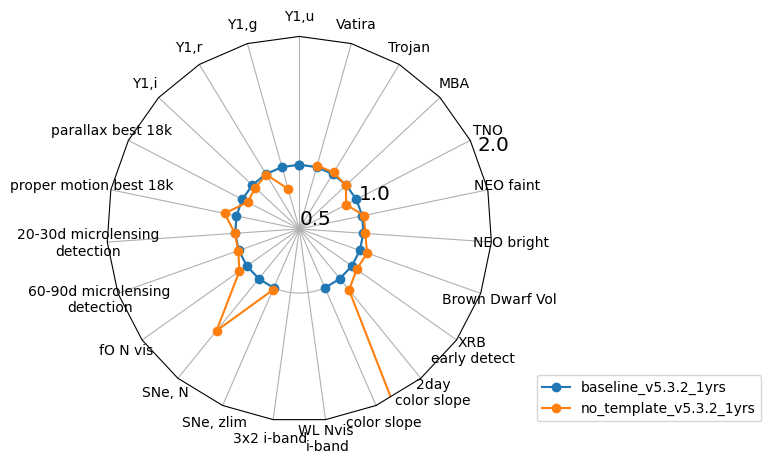

In [12]:
runs = [ 'baseline_v5.3.2_1yrs', 'no_template_v5.3.2_1yrs']
ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.2_1yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.5, 1.0, 2], bbox_to_anchor=(1.7, 0))


In [13]:
ndata

,"Y1,u","Y1,g","Y1,r","Y1,i",parallax best 18k,proper motion best 18k,20-30d microlensing\ndetection,60-90d microlensing\ndetection,fO N vis,"SNe, N",...,color slope,2day\ncolor slope,XRB\nearly detect,Brown Dwarf Vol,NEO bright,NEO faint,TNO,MBA,Trojan,Vatira
run_name,,,,,,,,,,,,,,,,,,,,,
baseline_v5.3.2_1yrs,1.00000,1.000000,1.000000,1.00000,1.000000,1.0000,1.0000,1.000,1.000000,1.000000,...,1.000000,1.000,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,1.0000
no_template_v5.3.2_1yrs,0.43593,0.823529,0.995306,0.96948,0.953588,1.0943,1.0039,1.005,1.071429,1.522377,...,5.379261,1.114,1.047297,1.060621,1.0154,1.013661,0.911347,0.995885,1.015079,1.0131
